# Pairwise conflict — the simulation parameters

This notebook is a guided tour of the knobs that shape a pairwise encounter. We fix one baseline scenario, then change **one parameter at a time** and plot what happens, so you can see what each does and where its default sits. It builds on [`01_pairwise_conflict.ipynb`](01_pairwise_conflict.ipynb) — start there for the basics.

The parameters fall into five groups:

1. **Encounter geometry** — `dpsi` (crossing angle), `dcpa` (design miss distance), `tlos`, speed.
2. **Separation logic** — `rpz` (protected zone), `t_lookahead`, the `resolver` and its `margin`, the `recovery` rule.
3. **CNS uncertainty** — `pos_ci95` / `vel_ci95` (navigation noise).
4. **Environment** — `wind`.
5. **Numerics & termination** — `dt`, `done_timeout`, `stop_within`, `t_max`.

In [1]:
# Install once (from the repo root, in a terminal):  pip install -e ".[examples]"
# %pip install -e "..[examples]"

## The baseline, and a `run` helper

Every experiment below starts from one baseline and overrides a single key. `run(**overrides)` builds the two-aircraft encounter (a multirotor crossed by a fixed-wing), applies the overrides, and returns a **recorded** `FleetOutcome`. Two small plot helpers turn those runs into comparisons: `sep_curves` overlays separation-vs-time (best for *how close, and when*), and we use `plot_pairwise` for the ground tracks when the *path* is the point.

The baseline runs with **no navigation noise**, so the quantitative comparisons are clean; the CNS section switches noise on.

In [1]:
%matplotlib inline
from dataclasses import replace
import matplotlib.pyplot as plt

from opencdarr.fleet import Agent, run_fleet
from opencdarr.dynamics import FixedWing, Multirotor
from opencdarr.performance import M600, SMALL_FIXEDWING
from opencdarr.autopilot import WaypointAutopilot
from opencdarr.mission import Mission
from opencdarr.scenario import create_conflict
from opencdarr.state import AircraftState
from opencdarr import geo, rng
from opencdarr.cd import StateBased
from opencdarr.cr import MVP, VO
from opencdarr.crr import PastCPA, FTR
from opencdarr.cns.navigation import GnssNavigation
from opencdarr.wind import WindField, NO_WIND
from opencdarr.viz import extract_tracks, plot_pairwise, plot_pairwise_montecarlo

# --- the baseline scenario (every default the tour departs from) ---
BASE = dict(
    speed=18.0, dpsi=90.0, dcpa=0.0, tlos=30.0, gs_intr=15.0, wp_dist=800.0,  # geometry
    rpz=50.0, t_lookahead=20.0, resolver='mvp', margin=1.1, recovery='pastcpa',  # separation
    pos_ci95=0.0, vel_ci95=0.0, wind=None,  # environment (off by default)
    dt=0.5, done_timeout=60.0, stop_within=100.0, seed=20260725,  # numerics & termination
)

def run(**overrides):
    """Build the baseline pairwise encounter with `overrides` applied, run it, return the record."""
    c = {**BASE, **overrides}
    own = AircraftState(id='COPTER', lat=52.0, lon=4.0, trk=0.0, gs=c['speed'], yaw=0.0)
    intr = create_conflict(own, intr_id='PLANE', dpsi=c['dpsi'], dcpa=c['dcpa'],
                           tlos=c['tlos'], rpz=c['rpz'], gs_intr=c['gs_intr'], side=1)
    own = replace(own, pos_ci95=c['pos_ci95'], vel_ci95=c['vel_ci95'])
    intr = replace(intr, pos_ci95=c['pos_ci95'], vel_ci95=c['vel_ci95'])
    wp_o = geo.forward(own.lat, own.lon, own.trk, c['wp_dist'])
    wp_i = geo.forward(intr.lat, intr.lon, intr.trk, c['wp_dist'])
    agents = [
        Agent(own, M600, Multirotor(), WaypointAutopilot(Mission(goto=wp_o))),
        Agent(intr, SMALL_FIXEDWING, FixedWing(),
              WaypointAutopilot(Mission(goto=wp_i), cruise_airspeed=c['gs_intr'])),
    ]
    resolver = {'mvp': MVP(margin=c['margin']), 'vo': VO(margin=c['margin']), None: None}[c['resolver']]
    recovery = {'pastcpa': PastCPA(bouncing_guard=True), 'ftr': FTR(), None: None}[c['recovery']]
    noisy = c['pos_ci95'] > 0 or c['vel_ci95'] > 0
    nav = GnssNavigation() if noisy else None
    gen = rng.generator(rng.root_seed_sequence(c['seed'])) if noisy else None
    return run_fleet(
        agents, rpz=c['rpz'], t_lookahead=c['t_lookahead'], dt=c['dt'],
        detector=StateBased(), resolver=resolver, recovery=recovery,
        wind=c['wind'] or NO_WIND, navigation=nav, rng=gen,
        done_timeout=c['done_timeout'], stop_within=c['stop_within'], record=True,
    )

def sep_curves(cases, rpz=50.0, title=''):
    """Overlay separation-vs-time for a list of (label, run) cases."""
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for label, r in cases:
        t = extract_tracks(r)
        ax.plot(t.times, t.separation, lw=1.8, label=label)
    ax.axhline(rpz, ls='--', color='0.4', lw=1.0, label=f'rpz = {rpz:g} m')
    ax.set_xlabel('time [s]'); ax.set_ylabel('separation [m]'); ax.set_ylim(bottom=0)
    ax.legend(frameon=False); ax.set_title(title); fig.tight_layout()
    return fig

base = run()
print(f'baseline: min_sep = {base.min_sep:.1f} m, los = {base.los}, ended t = {base.frames[-1].t:.1f} s')

baseline: min_sep = 67.2 m, los = False, ended t = 51.0 s


## 1. Encounter geometry

`create_conflict` places the intruder so the two legs would lose separation `tlos` seconds from now. Three knobs set the shape:

- **`dpsi`** — the intruder's crossing angle relative to ownship (deg). 90° is a right-angle crossing; near 180° is head-on; near 0° is a slow overtake.
- **`dcpa`** — the *design* miss distance at closest approach with no action (m). `dcpa=0` is a dead-on collision course; a larger `dcpa` is a glancing pass that may not even breach `rpz`.
- **`tlos`** — seconds until that loss of separation, i.e. how far ahead the encounter sits.

### Crossing angle `dpsi`
A shallower or steeper crossing changes the closing geometry and how the manoeuvre plays out.

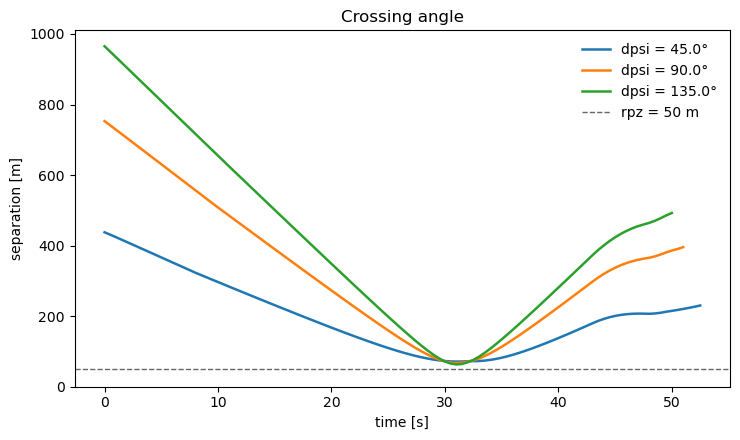

In [4]:
fig = sep_curves([(f'dpsi = {a}°', run(dpsi=a)) for a in (45.0, 90.0, 135.0)],
           rpz=50.0, title='Crossing angle')

### Design miss distance `dcpa`
With `dcpa=0` the unresolved paths collide; increase it and the encounter is a near-miss that the resolver has to do less about — beyond `rpz` it is not even a conflict. The ground tracks show the geometry most clearly:

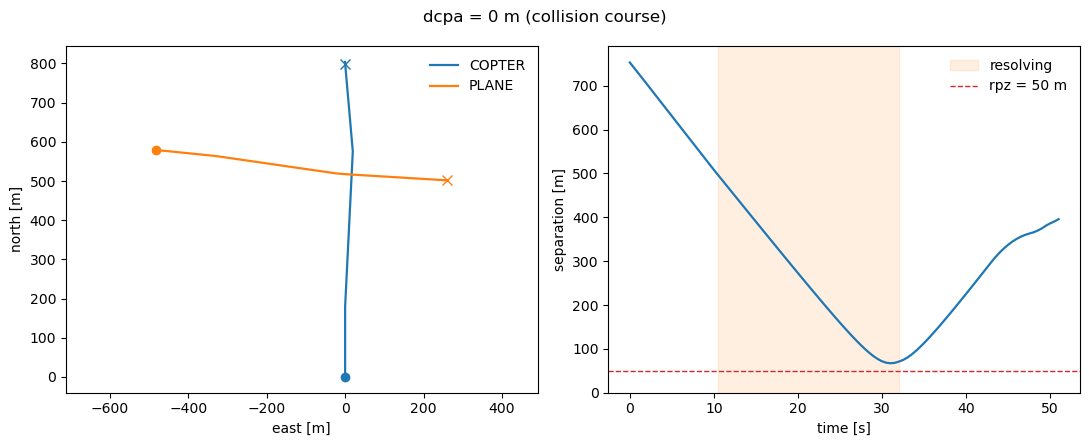

In [5]:
fig = plot_pairwise(run(dcpa=0.0), rpz=50.0, title='dcpa = 0 m (collision course)')

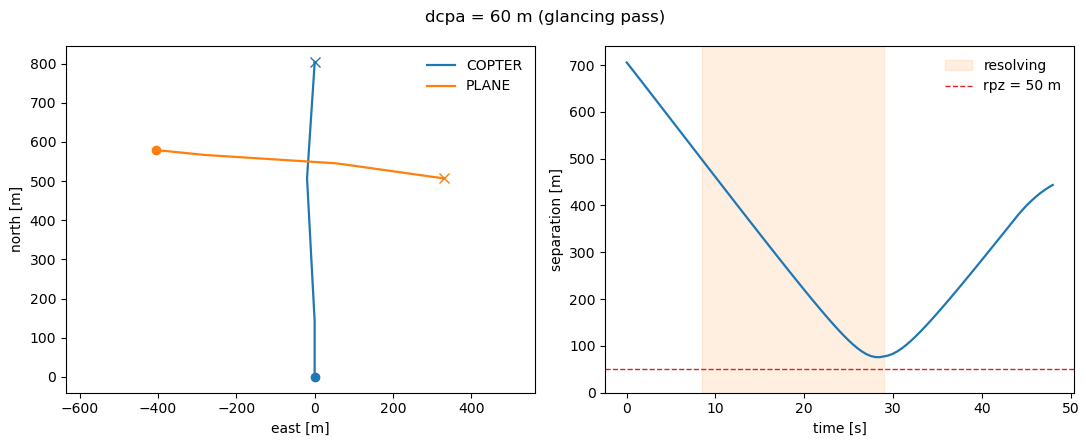

In [12]:
fig = plot_pairwise(run(dcpa=60.0), rpz=50.0, title='dcpa = 60 m (glancing pass)')

## 2. Separation logic

This is the CD&R core — how the aircraft detect and avoid each other.

- **`rpz`** — the protected-zone radius (m). It is the safety bubble the resolver keeps clear, *and* it sets what counts as loss of separation. Note it does double duty: `create_conflict` also uses it to place the encounter, so raising `rpz` both enlarges the bubble and tightens the geometry. Default **50 m**.
- **`t_lookahead`** — how many seconds ahead detection projects (s). Longer sight → earlier reaction. Default **20 s**.
- **`resolver`** + **`margin`** — the avoidance manoeuvre (`MVP`, `VO`, or none) and how much extra room beyond `rpz` it aims for. Default **MVP, margin 1.1**.
- **`recovery`** — when to stop avoiding and return to the mission (`PastCPA`, `FTR`, or none).

### Protected zone `rpz`
A bigger bubble means the resolver holds the aircraft further apart (and, here, a tighter start).

rpz =   30 m  ->  min_sep =  30.5 m   los = False
rpz =   50 m  ->  min_sep =  67.2 m   los = False
rpz =   80 m  ->  min_sep = 115.6 m   los = False


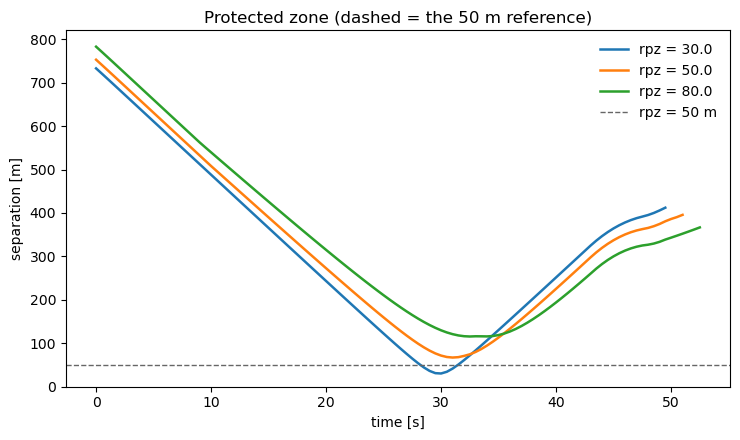

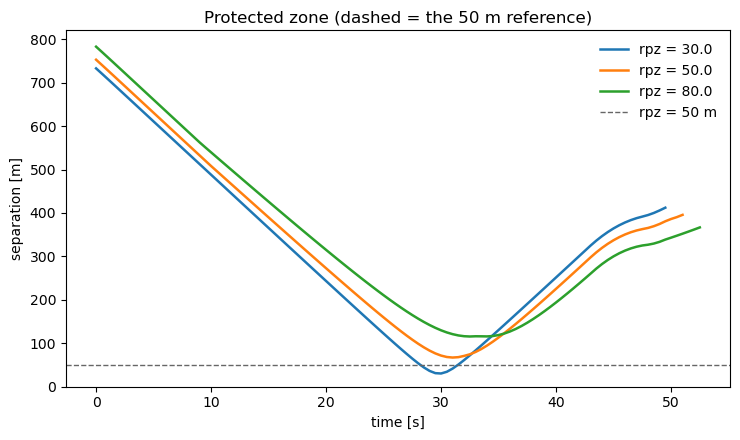

In [15]:
# each run is compared against its own rpz line, so annotate the min separation instead
for r in (30.0, 50.0, 80.0):
    o = run(rpz=r)
    print(f'rpz = {r:4.0f} m  ->  min_sep = {o.min_sep:5.1f} m   los = {o.los}')
sep_curves([(f'rpz = {r}', run(rpz=r)) for r in (30.0, 50.0, 80.0)],
           rpz=50, title='Protected zone (dashed = the 50 m reference)')

### Lookahead `t_lookahead`
A longer lookahead detects the conflict earlier, so the avoidance starts sooner and is gentler; too short and the aircraft reacts late.

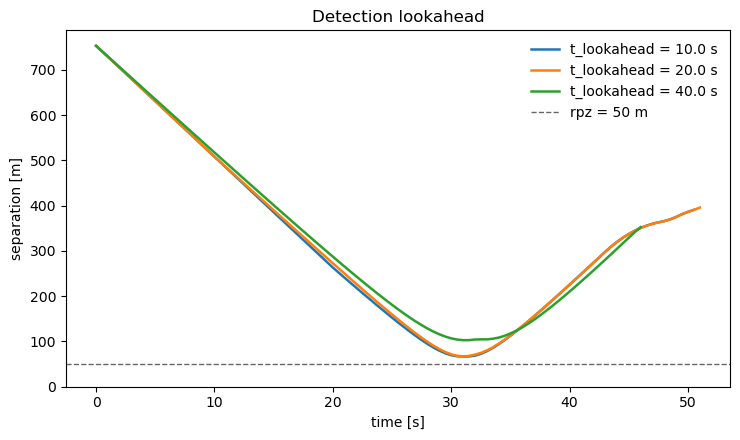

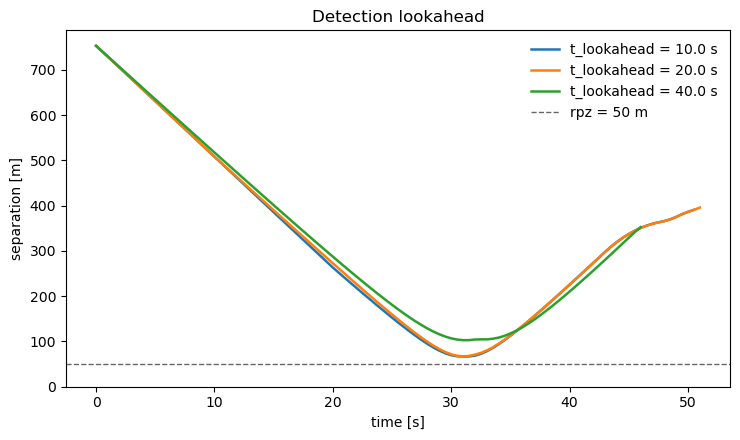

In [7]:
sep_curves([(f't_lookahead = {t} s', run(t_lookahead=t)) for t in (10.0, 20.0, 40.0)],
           rpz=50.0, title='Detection lookahead')

### Resolver margin
`MVP` steers to clear `rpz × margin`. A larger margin buys a wider berth — a bigger closest approach — at the cost of a larger deviation.

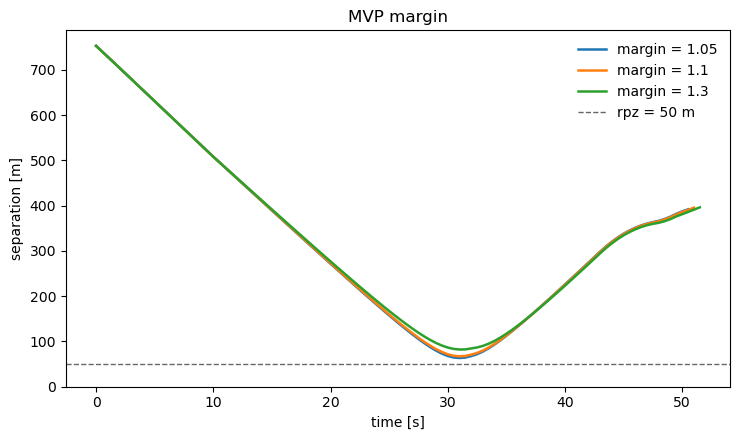

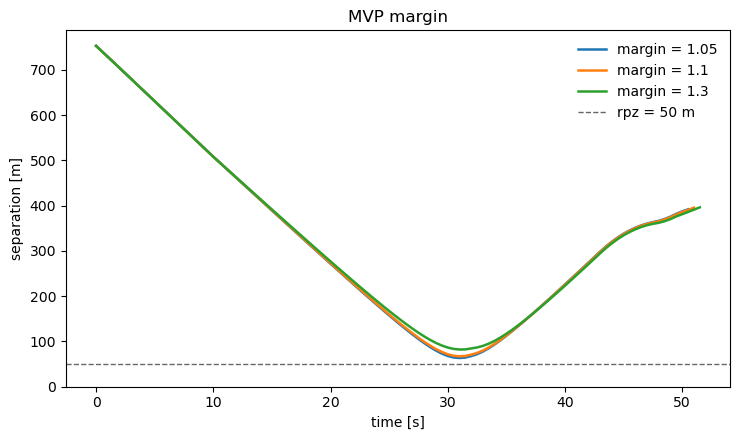

In [8]:
sep_curves([(f'margin = {m}', run(margin=m)) for m in (1.05, 1.1, 1.3)],
           rpz=50.0, title='MVP margin')

### Resolver type — and no resolver at all
With **no resolver** the aircraft fly their missions straight into a loss of separation — the baseline the CD&R is measured against. `MVP` (a geometric velocity nudge) and `VO` (velocity obstacles) are the two provided resolvers.

> The `VO` implementation here is our own and still being validated — read its curve as illustrative, not a benchmark of velocity-obstacle methods in general.

no resolver   min_sep =  31.2 m   los = True
MVP           min_sep =  67.2 m   los = False
VO            min_sep =  68.0 m   los = False


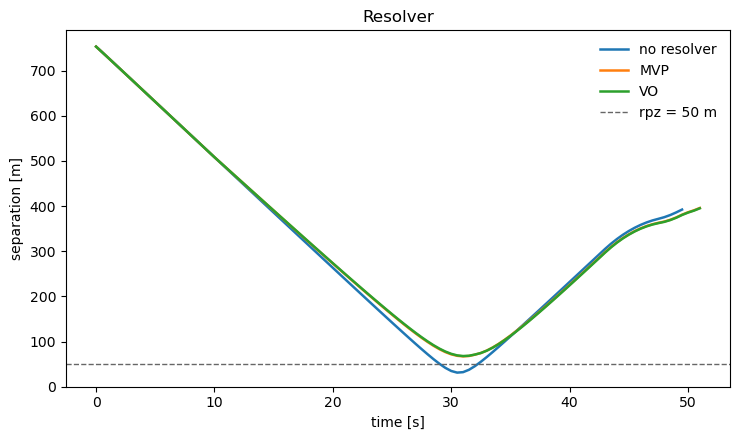

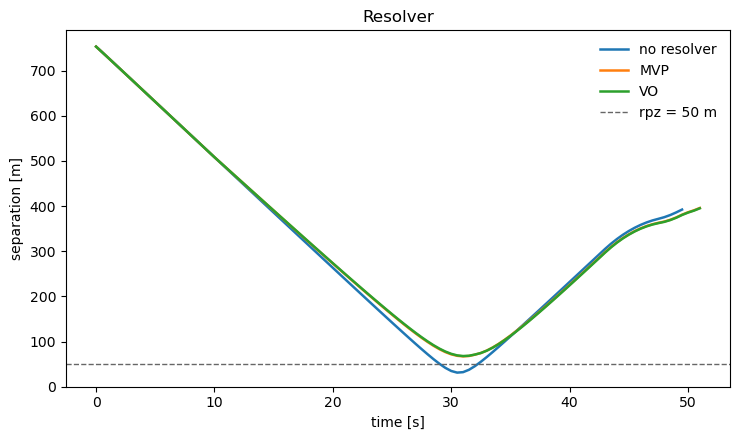

In [9]:
cases = [('no resolver', run(resolver=None, recovery=None)),
         ('MVP', run(resolver='mvp')),
         ('VO', run(resolver='vo'))]
for label, o in cases:
    print(f'{label:12s}  min_sep = {o.min_sep:5.1f} m   los = {o.los}')
sep_curves(cases, rpz=50.0, title='Resolver')

### Recovery criterion
Recovery decides *when the avoidance ends and the aircraft turns back to its mission*. `PastCPA` waits until the pair is past its closest point of approach; `FTR` (first-turn resumption) returns as soon as the avoidance turn is made. The return path differs — compare the ground tracks:

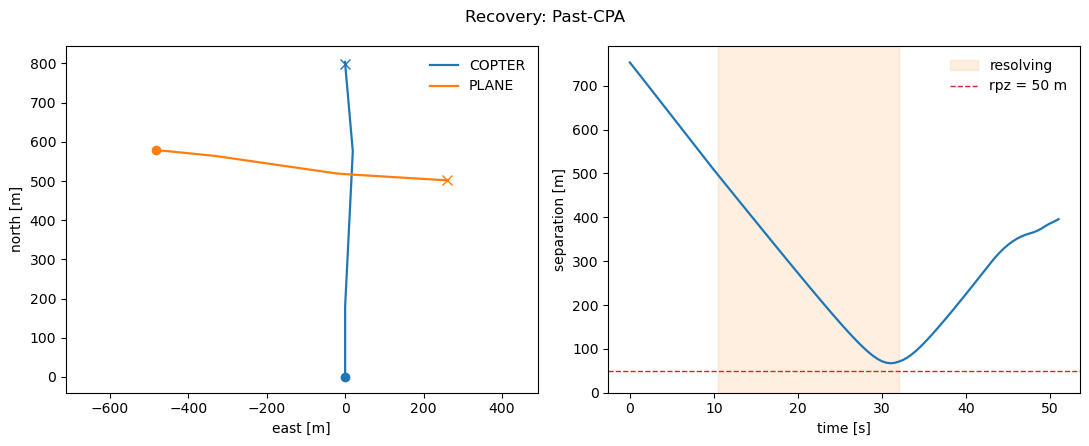

In [10]:
fig = plot_pairwise(run(recovery='pastcpa'), rpz=50.0, title='Recovery: Past-CPA')

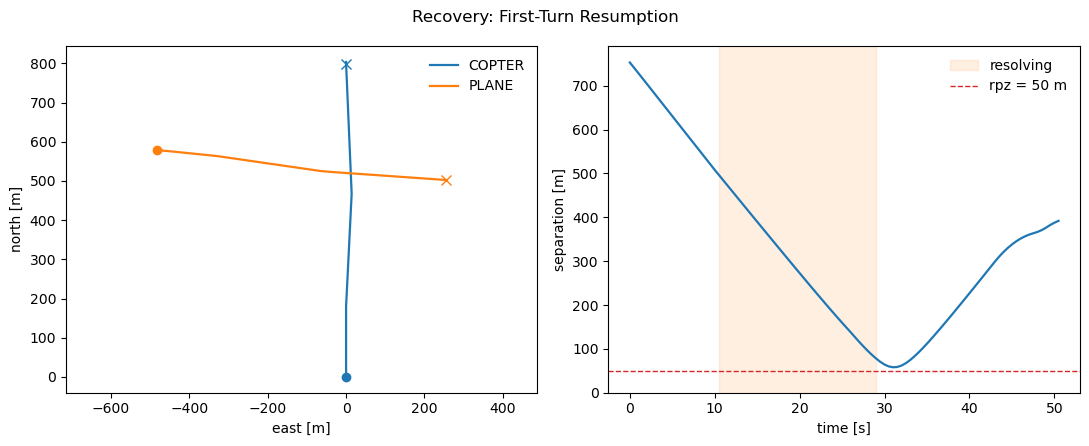

In [11]:
fig = plot_pairwise(run(recovery='ftr'), rpz=50.0, title='Recovery: First-Turn Resumption')

## 3. CNS uncertainty

So far the aircraft knew their own and each other's states exactly. **`pos_ci95`** and **`vel_ci95`** put a 95%-confidence error (m and m/s) on each aircraft's self-fix, delivered through a `GnssNavigation` layer. Because the manoeuvres now act on a *noisy* fix, one seed is just one draw — so we run a small Monte-Carlo sweep at each noise level and overlay the trajectories. More noise → more dispersion, and a fatter tail creeping toward `rpz`.

In [12]:
def sweep(pos_ci95, n=40):
    return [run(pos_ci95=pos_ci95, vel_ci95=pos_ci95 / 10.0, seed=1000 + i) for i in range(n)]

for pos in (0.0, 15.0, 30.0):
    runs = sweep(pos) if pos else [run()]
    mins = [o.min_sep for o in runs]
    lost = sum(o.los for o in runs)
    print(f'pos_ci95 = {pos:4.0f} m:  min over sweep {min(mins):5.1f} m   LoS {lost}/{len(runs)}')

pos_ci95 =    0 m:  min over sweep  67.2 m   LoS 0/1


pos_ci95 =   15 m:  min over sweep  58.9 m   LoS 0/40


pos_ci95 =   30 m:  min over sweep  71.8 m   LoS 0/40


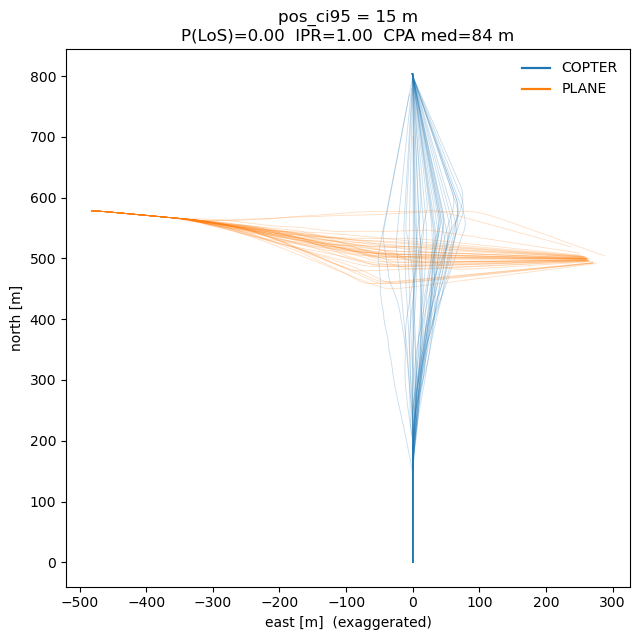

In [13]:
fig = plot_pairwise_montecarlo(sweep(15.0), title='pos_ci95 = 15 m')

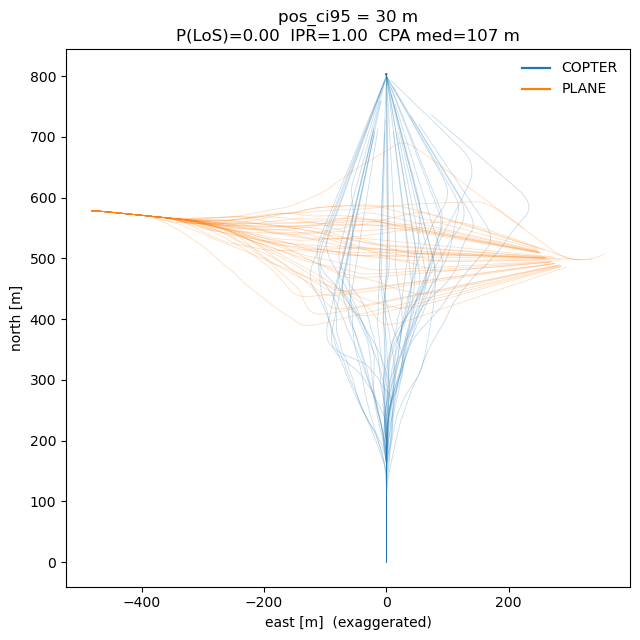

In [14]:
fig = plot_pairwise_montecarlo(sweep(30.0), title='pos_ci95 = 30 m')

## 4. Wind

`wind` is a steady, uniform field the loop threads into the dynamics (default `NO_WIND`). It acts on the *true* motion: the fixed-wing crabs into it to hold its ground course, and its ground speed along the leg changes with heading. Because that retimes when the two aircraft actually meet, wind can move the closest approach — here an 8 m/s crosswind pushes it from ~67 m out to ~100 m. Build a field from the meteorological convention (the bearing it blows *from*) with `WindField.from_met(coming_from_deg, speed)`.

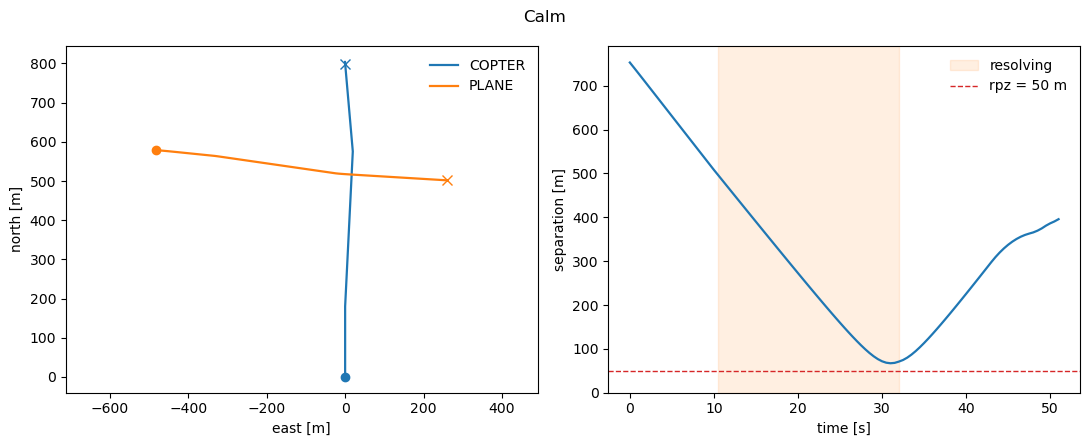

In [15]:
fig = plot_pairwise(run(wind=None), rpz=50.0, title='Calm')

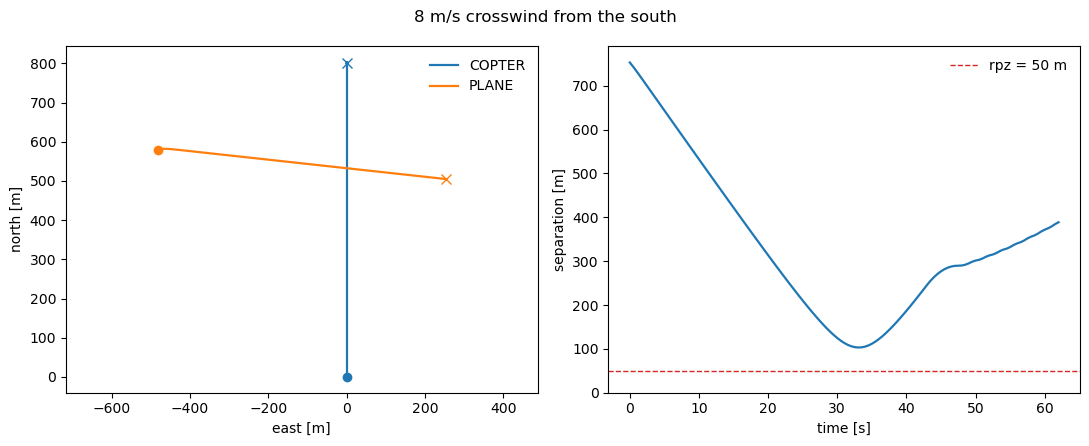

In [16]:
south_wind = WindField.from_met(180.0, 8.0)   # 8 m/s from the south
fig = plot_pairwise(run(wind=south_wind), rpz=50.0, title='8 m/s crosswind from the south')

## 5. Numerics and termination

- **`dt`** — the integration timestep (s), default **0.5**. It is a *numerical* knob, not a physical one: halving it should barely move the result — that near-overlap is the check that the sim has converged.
- **`done_timeout`** — seconds the fleet must stay clear (past CPA, separated, nobody resolving) before the run ends, default **10 s** (we use 60 here so arrival wins — see below).
- **`stop_within`** — if set, also end once every aircraft is within this many metres of its waypoint. A fixed-wing *orbits* its goal at ~80 m, so use ≥ that.
- **`t_max`** — a hard cap (s), default **600** — the run can never exceed it.

### Timestep `dt` — a convergence check
The curves should nearly coincide; if they don't, the step is too coarse for this manoeuvre.

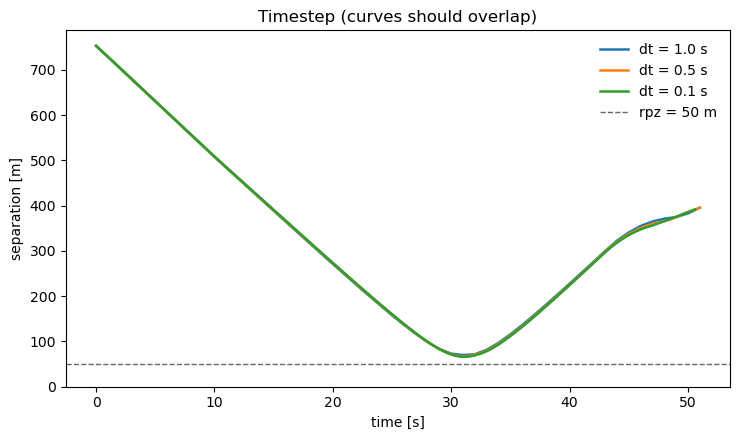

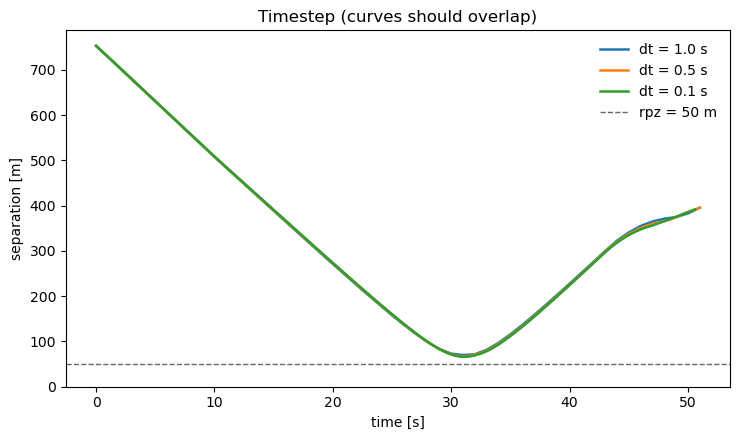

In [17]:
sep_curves([(f'dt = {d} s', run(dt=d)) for d in (1.0, 0.5, 0.1)],
           rpz=50.0, title='Timestep (curves should overlap)')

### Termination — `done_timeout` vs `stop_within`
The run ends at the **earliest** trigger. With the default short `done_timeout` it stops soon after the conflict clears; with `stop_within` (and a generous `done_timeout`) it instead runs each aircraft to its waypoint. Watch the end time move:

In [18]:
print(f"conflict-cleared stop (done_timeout=10, no stop_within): "
      f"{run(done_timeout=10.0, stop_within=None).frames[-1].t:.1f} s")
print(f"waypoint stop (stop_within=100, done_timeout=60):        "
      f"{run(done_timeout=60.0, stop_within=100.0).frames[-1].t:.1f} s")

conflict-cleared stop (done_timeout=10, no stop_within): 42.0 s
waypoint stop (stop_within=100, done_timeout=60):        51.0 s


## Recap

| group | parameter | default | raising it… |
|---|---|---|---|
| geometry | `dpsi` | — | changes the crossing angle |
| geometry | `dcpa` | — | widens the unresolved miss (less of a conflict) |
| geometry | `tlos` | — | pushes the encounter further ahead |
| separation | `rpz` | 50 m | bigger safety bubble (and tighter start) |
| separation | `t_lookahead` | 20 s | reacts earlier, more gently |
| separation | `margin` | 1.1 | wider berth, larger deviation |
| separation | `resolver` | MVP | none → guaranteed LoS; MVP/VO avoid |
| separation | `recovery` | Past-CPA | changes when the aircraft returns to mission |
| CNS | `pos_ci95` / `vel_ci95` | 0 | more trajectory dispersion |
| environment | `wind` | none | bends the ground track; the fixed-wing crabs |
| numerics | `dt` | 0.5 s | coarser integration (should not change the answer) |
| termination | `done_timeout` / `stop_within` / `t_max` | 10 / none / 600 s | when the run ends |

Every one is a single keyword to `run_fleet` — change one argument and re-run.